# Data Pre-Processing

**Import Packages and CSV**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None) # None: display all columns, 100: display 100 columns, etc.

df = pd.read_csv("D:\\2025\\MLOPS-Project-US-Visa\\notebook\\EasyVisa.csv")
print(df.shape)

(25480, 12)


## 1. Data Cleaning

* Handling missing value
* Handling duplicate
* Check data type
* Understand the dataset

**Handling missing value**

In [2]:
feature_with_na = [feature for feature in df.columns if df[feature].isnull().sum() >= 1]

for feature in feature_with_na:
    print(feature, np.round(df[feature].isnull().mean()*100, 5), '% missing values')

In [3]:
feature_with_na

[]

**Report**
* No null value in the dataset

**Handling duplicate value**

In [4]:
print(df.duplicated().sum())

0


**Report**
* No duplicate in the dataset

** Remove case_id from the dataset as it cannot used in Model Training**

In [5]:
df.drop('case_id', axis=1, inplace=True) # axis=1: columns, axis=0: rows, inplace=True: modify the original dataframe, inplace=False: return a new dataframe

# 2. Feature Engineering 

## 2.1 Feature Extraction

In [6]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [7]:
from datetime import date
today_date = date.today() # date.today() returns the current local date as a datetime.date object.
current_year = today_date.year
current_year

2026

**Subtract current_year with yr_of_estab to get company's age**

In [8]:
df['company_age'] = current_year - df['yr_of_estab']
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


**Drop yr_of_estab feature**

In [9]:
df.drop('yr_of_estab', axis=1, inplace=True)

### Type of feature

**Categorical Features**

In [10]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 8


**Numeric Features**

In [11]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 3


**Discrete features**

In [12]:
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 0


**Continues Features**

In [13]:
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 3


### Split X and Y

* Split Dataframe to X and y
* Here we set a variable X i.e, independent columns, and a variable y i.e, dependent column as the `case_status` column.

In [14]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [15]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

**Manual encoding target column**

In [16]:
y = np.where(y=='Denied', 1, 0) # if y is 'Denied', then 1, else 0

In [17]:
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

## 2.2 Feature Transformation

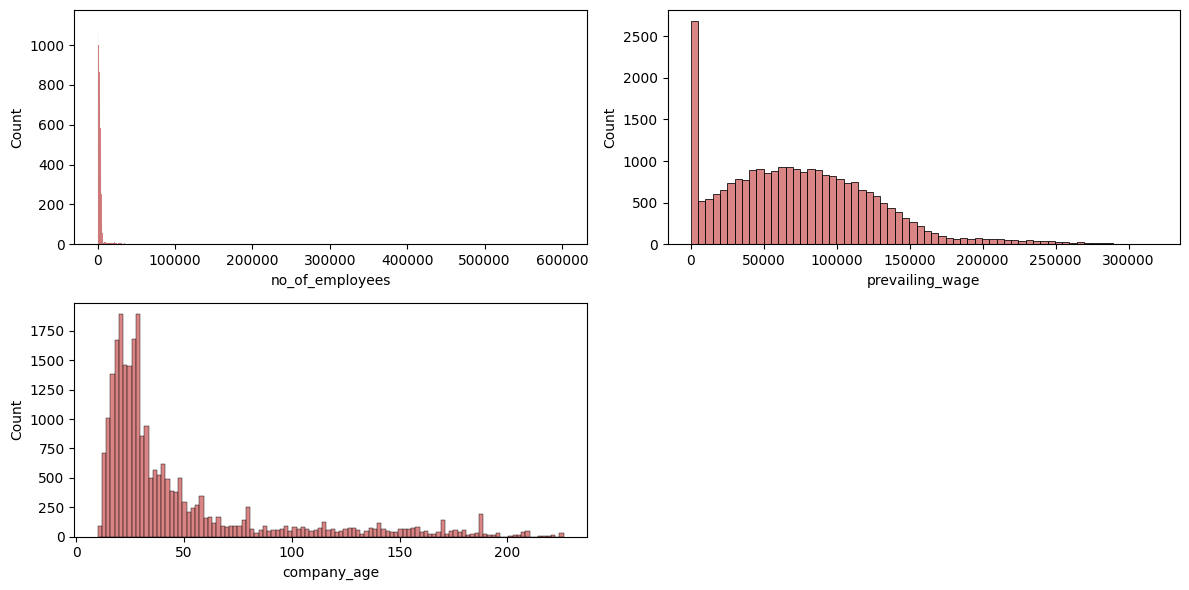

In [18]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees','prevailing_wage','company_age']): # numerical features
    plt.subplot(2, 2, i+1) # 2 rows, 2 columns, i+1: position of the subplot
    sns.histplot(x=X[col], color='indianred') # histplot: for numerical features
    plt.xlabel(col)
    plt.tight_layout() # tight_layout: adjust the padding between and around subplots to prevent overlap
plt.show()

* No of employees and Copmany age column is skewed
* Apply a power transform featurewise to make data more Gaussian-like.

Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

**What is skewness?**
* Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

**Checking skewness**

In [19]:
X[continuous_features].skew(axis=0, skipna=True) # axis=0: columns, axis=1: rows, skipna=True: ignore NaN values

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

* Positiviely Skewed : company_age, no_of_employees.
* We can handle outliers and then check the skewness.

### Apply power transformer to check if it can reduces the outliers

In [20]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson') # method='yeo-johnson': can handle both positive and negative values, method='box-cox': can only handle positive values
transform_features = ['no_of_employees', 'company_age']
X_copy = pt.fit_transform(X[transform_features])

In [21]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

In [22]:
X_copy

,no_of_employees,company_age
0,1.517300,-0.958506
1,0.030912,-0.470816
2,2.885076,-1.080479
3,-1.343550,1.632700
4,-0.432287,-0.741917
...,...,...
25475,0.079917,-1.080479
25476,0.235747,-0.846032
25477,-0.413885,1.552921
25478,-0.111949,1.685772


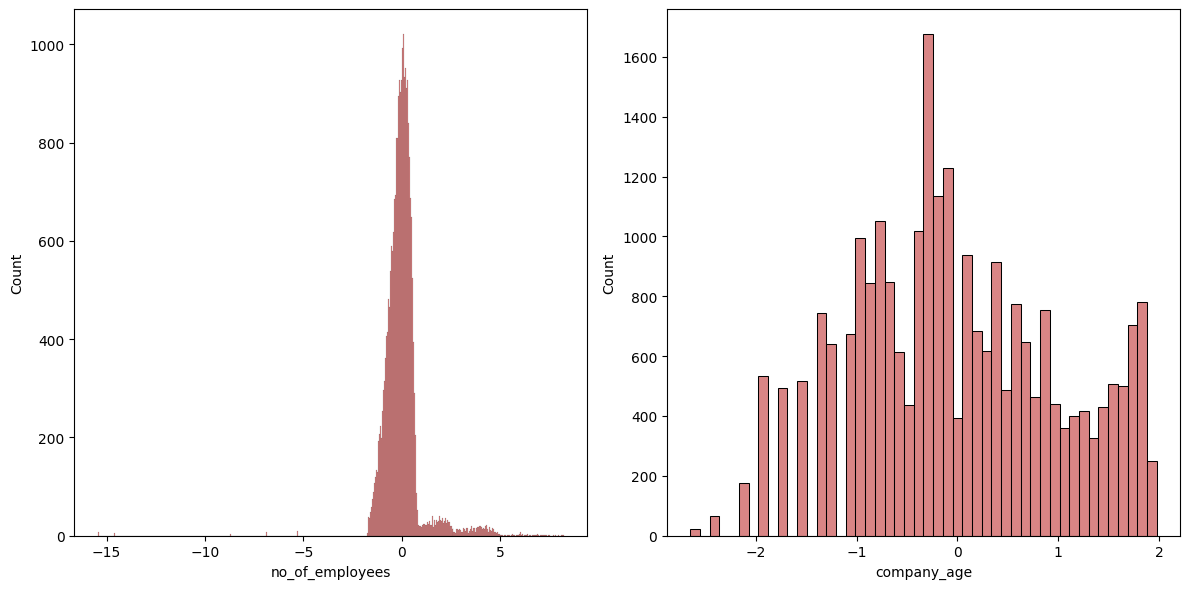

In [23]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()
plt.show()

**Checking skewness**

In [24]:
X_copy.skew(axis=0, skipna=True)

no_of_employees    0.399339
company_age        0.120823
dtype: float64

* Here Yeo-Johnson is used and it supports both positive or negative data for transformation.
* So Power Transformer with yeo-johnson can be used.

In [25]:
for feature in cat_features:
    print(feature, ":", df[feature].nunique(), "unique values")

continent : 6 unique values
education_of_employee : 4 unique values
has_job_experience : 2 unique values
requires_job_training : 2 unique values
region_of_employment : 5 unique values
unit_of_wage : 4 unique values
full_time_position : 2 unique values
case_status : 2 unique values


## 2.3 Feature Encoding and Scaling

**One Hot Encoding for Columns which had lesser unique values and not ordinal**
* One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

**Ordinal Encoding for Columns which has many unique categories**
* Ordinal encoding is used here as label encoder is supported for column transformer.
* Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.

**Standard Scaler**
* Standardize features by removing the mean and scaling to unit variance.

**Power Transformer**
* Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

**Selecting number features for preprocessing**

In [26]:
num_features = list(X.select_dtypes(exclude='O').columns)
num_features

['no_of_employees', 'prevailing_wage', 'company_age']

### Preprocessing using Column Transformer

In [27]:
# Ordinal columns
or_columns = ['has_job_experience','requires_job_training','full_time_position','education_of_employee'] # eg: low, medium, high -> low=1, medium=2, high=3

# One-hot columns
oh_columns = ['continent','unit_of_wage','region_of_employment'] # eg: dog, cat, mouse -> dog=[1,0,0], cat=[0,1,0], mouse=[0,0,1]

# Transform columns
transform_columns = ['no_of_employees', 'company_age']

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = StandardScaler() # StandardScaler: standardize features by removing the mean and scaling to unit variance
oh_transformer = OneHotEncoder(handle_unknown='error') # handle_unknown='ignore': ignore unknown categories during transform, handle_unknown='error': raise an error if an unknown category is encountered during transform
ordinal_transformer = OrdinalEncoder(handle_unknown='error') 

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer(transformers=
                                 [
                                     ("OneHotEncoder", oh_transformer, oh_columns),
                                     ("OrdinalEncoder", ordinal_transformer, or_columns),
                                     ("Transformer", transform_pipe, transform_columns),
                                     ("StandardScaler", numeric_transformer, num_features)
                                 ])

In [28]:
X = preprocessor.fit_transform(X)

In [29]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]], shape=(25480, 24))

# 3. Classification

In [30]:
from imblearn.combine import SMOTETomek, SMOTEENN

# SMOTEENN: SMOTE + Edited Nearest Neighbors, SMOTETomek: SMOTE + Tomek Links
smt = SMOTEENN(random_state=42, sampling_strategy='minority')

X_res, y_res = smt.fit_resample(X, y)

## 3.1 Train Test split

* The train-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.
* It is a fast and easy procedure to perform, the results of which allow you to compare the performance of machine learning algorithms.

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((13644, 24), (3412, 24))

In [32]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

In [33]:
def evaluate_clf(groundtruth, predict):
    acc = accuracy_score(groundtruth, predict)
    precision = precision_score(groundtruth, predict)
    recall = recall_score(groundtruth, predict)
    f1 = f1_score(groundtruth, predict)
    roc_auc = roc_auc_score(groundtruth, predict) # True Positive Rate (TPR) vs False Positive Rate (FPR) curve, AUC: Area Under the Curve
    
    return acc, precision, recall, f1, roc_auc

In [34]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoosting Classifier": CatBoostClassifier(verbose=False), # verbose=False: Hide the training log
    "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [35]:
# Usually, we pass X_train, y_train to train the model and X_test, y_test to evaluate the model.
# But here, we are passing the entire dataset to evaluate the model on the entire dataset.
def evaluate_model(X, y, models): 
    """_summary_

    Args:
        X: Training data
        y: Target values
        models: Dictionary of models to evaluate
    
    Returns:
        DataFrame containing the evaluation metrics for each model
    """
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    models_list = []
    accuracy_list = []
    auc = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i] # Get the model from the dictionary
        model.fit(X_train, y_train) # Train model
        
        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Training set evaluation
        model_train_accuracy, model_train_precision, model_train_recall, model_train_f1, model_train_roc_auc = evaluate_clf(y_train, y_train_pred)
        
        # Test set evaluation
        model_test_accuracy, model_test_precision, model_test_recall, model_test_f1, model_test_roc_auc = evaluate_clf(y_test, y_test_pred)
        
        print(list(models.keys())[i]) # Get the model 'name' from the dictionary
        models_list.append(list(models.keys())[i])
        accuracy_list.append(model_test_accuracy)
        auc.append(model_test_roc_auc)
        
        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_roc_auc))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_roc_auc))
        print('='*35)
        print('\n')
        
    # zip 
    report = pd.DataFrame(list(zip(models_list, accuracy_list, auc)), columns=['Model', 'Accuracy', 'Roc Auc']).sort_values(by='Accuracy', ascending=False)
    
    return report
        

## 3.2 Model Training

In [36]:
base_model_report = evaluate_model(X_res, y_res, models)

Random Forest
Model performance for Training set
- Accuracy: 0.9999
- F1 score: 0.9999
- Precision: 1.0000
- Recall: 0.9999
- Roc Auc Score: 0.9999
----------------------------------
Model performance for Test set
- Accuracy: 0.9528
- F1 score: 0.9563
- Precision: 0.9576
- Recall: 0.9550
- Roc Auc Score: 0.9526


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9241
- F1 score: 0.9295
- Precision: 0.9338
- Recall: 0.9252
- Roc Auc Score: 0.9240


Logistic Regression
Model performance for Training set
- Accuracy: 0.7375
- F1 score: 0.7528
- Precision: 0.7655
- Recall: 0.7406
- Roc Auc Score: 0.7373
----------------------------------
Model performance for Test set
- Accuracy: 0.7371
- F1 score: 0.7519
- Precision: 0.7682
- Recall: 0.7362
- Roc Auc Score: 0.7372


Gradient Boosting
Model performance for Training 

**Result of all models**

In [37]:
base_model_report

,Model,Accuracy,Roc Auc
0,Random Forest,0.952814,0.952615
4,K-Neighbors Classifier,0.941090,0.939407
5,XGBClassifier,0.936987,0.936826
6,CatBoosting Classifier,0.928195,0.929233
1,Decision Tree,0.924091,0.923988
3,Gradient Boosting,0.893318,0.892885
7,Support Vector Classifier,0.873681,0.873721
8,AdaBoost Classifier,0.863423,0.862691
2,Logistic Regression,0.737104,0.737186


**Here we use Random Forest, KNN, and XGB for Hyper Parameter tuning** 

In [44]:
xgboost_params = {
    # max_depth: maximum depth of a tree, range(3, 10, 2): 3, 5, 7, 9. Use odd numbers to prevent equal decides.
    # The bigger max_depth get the more complex the model (overfitting) 
    "max_depth": range(3, 10, 2),
    
    # min_child_weight: minimum sum of instance weight (hessian) needed in a child,
    # decision tree will stop splitting if the sum of instance weight (hessian) in a child is less than min_child_weight
    # The bigger min_child_weight get the more stopping splitting, the simpler the model (underfitting)
    "min_child_weight": range(1, 6, 2)
}

rf_params = {
    # None means that there is no limit on the depth of the tree,
    # and the tree will expand until all leaves are pure or until all leaves contain less than min_samples_split samples.
    "max_depth": [10, 12, None, 15, 20], 
    
    # The number of features to consider when looking for the best split:
    # Use less features to reduce the complexity of the model and prevent overfitting, but it may also reduce the accuracy of the model.
    "max_features": ['sqrt', 'log2', None],
    
    # The number of trees in the forest, the more trees, the better the performance, but it also increases the training time.
    "n_estimators": [10, 50, 100, 200]
}

# KNN does not have actual training process, it just stores the training data 
# and makes predictions based on the distance between the test data and the training data.
knn_params = {
    # algorithm used to compute the nearest neighbors, 
    # auto: automatically choose the best algorithm based on the values passed to fit method, 
    # ball_tree: BallTree algorithm, 
    # kd_tree: KDTree algorithm, 
    # brute: brute-force search.
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'], 

    # uniform: all points in each neighborhood are weighted equally, distance: weight points by the inverse of their distance
    "weights": ['uniform', 'distance'],
    
    "n_neighbors": [3, 4, 5, 7, 9] # The number of neighbors to use for k-neighbors queries.
}

In [45]:
randomcv_models = [
    ('XGBoost', XGBClassifier(), xgboost_params),
    ('RF', RandomForestClassifier(), rf_params),
    ('KNN', KNeighborsClassifier(), knn_params)
]

**Hyperparameters tuning loop**

In [46]:
 # Randomized search cross-validation, 
 # randomly choose a combination of hyperparameters from the specified distributions and evaluate the model performance for each combination.
 # It is more efficient than GridSearchCV when the hyperparameter space is large.
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, param in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=param,
        n_iter=100, # use 100 different combinations of hyperparameters
        cv=3, # 3-fold cross-validation
        verbose=2, # verbose=0: no output, verbose=1: print a message for each combination of hyperparameters, verbose=2: print a message for each fold and combination of hyperparameters
        n_jobs=-1, # use all available CPU cores to run the search
    )
    
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_ # best_params_: the combination of hyperparameters that gives the best performance
    
for name in model_param:
    print(f"---------------- Best Params for {name} -------------------")
    print(model_param[name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits
---------------- Best Params for XGBoost -------------------
{'min_child_weight': 1, 'max_depth': 9}
---------------- Best Params for RF -------------------
{'n_estimators': 200, 'max_features': 'log2', 'max_depth': None}
---------------- Best Params for KNN -------------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [47]:
model_param

{'XGBoost': {'min_child_weight': 1, 'max_depth': 9},
 'RF': {'n_estimators': 200, 'max_features': 'log2', 'max_depth': None},
 'KNN': {'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}}

## 3.3 Retraining the model with best Parameters

In [48]:
# "**" is used to unpack the dictionary of hyperparameters and pass them as keyword arguments to the model constructor.
best_model = {
    "Random Forest Classifier": RandomForestClassifier(**model_param['RF']),
    "KNeighbors Classifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBClassifier": XGBClassifier(**model_param['XGBoost'])
}

tuned_report = evaluate_model(X = X_res, y = y_res, models=best_model)

Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9522
- F1 score: 0.9559
- Precision: 0.9546
- Recall: 0.9572
- Roc Auc Score: 0.9518


KNeighbors Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9719
- F1 score: 0.9743
- Precision: 0.9620
- Recall: 0.9870
- Roc Auc Score: 0.9705


XGBClassifier
Model performance for Training set
- Accuracy: 0.9994
- F1 score: 0.9995
- Precision: 0.9993
- Recall: 0.9996
- Roc Auc Score: 0.9994
----------------------------------
Model performance for Test set
- Accuracy: 0.9461
- F1 score: 0.9501
- Precision: 0.9521
- Recall: 0.9480
- Roc Auc Score: 0.9459




In [49]:
tuned_report

,Model,Accuracy,Roc Auc
1,KNeighbors Classifier,0.971864,0.970511
0,Random Forest Classifier,0.952227,0.951782
2,XGBClassifier,0.946073,0.945901


In [ ]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("FINAL MODEL: KNN")
print ("Accuracy Score value: {:.4f}".format(score))
print(cr)

FINAL MODEL: KNN
Accuracy Score value: 0.9719
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1566
           1       0.96      0.99      0.97      1846

    accuracy                           0.97      3412
   macro avg       0.97      0.97      0.97      3412
weighted avg       0.97      0.97      0.97      3412



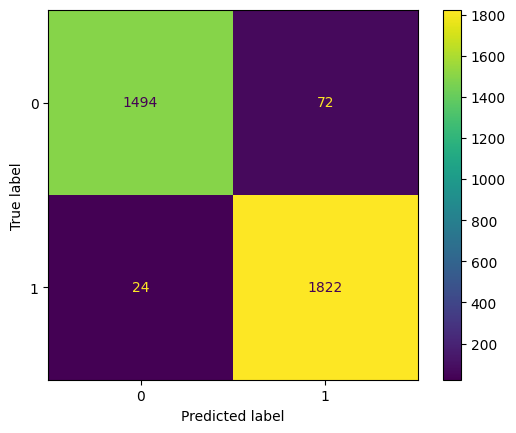

In [58]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

# Best model is K-Nearest Neighbor(KNN) with accuracy 97,19%